checkpointing stored the state based on threads. 
another threads doen't know about it. 

so to share the memory across the threads and store the user's long term memory, langgraph provides the `Store` abstraction for this. 

it is a key-value db. saving and retrieving happens using `namespaces`.

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.store.memory import InMemoryStore
from langchain_core.runnables import RunnableConfig

here for simplicity using InMemoryStore that behaves like the prod-ready PostgresStore or RedisStore. 

In [12]:
store = InMemoryStore()

namespaces is a tuple ("users", "alice", "preferences") that identifies where to store data. Like its a path. it has. 
- put(namespace, key, value)
- get(namespace, key)
- search(namespace)

In [13]:
namespace = ("users", "unique", "preferences")
store.put(namespace, "tone", {"preferred_tone": "concise", "urgency_threshold": "high"})

value = store.get(namespace, "tone")
value

Item(namespace=['users', 'unique', 'preferences'], key='tone', value={'preferred_tone': 'concise', 'urgency_threshold': 'high'}, created_at='2026-08-20T15:49:34.016964+00:00', updated_at='2026-08-20T15:49:34.016967+00:00')

In [14]:
class State(TypedDict):
    user_id: str
    message: str


In [19]:
def remember_preference(state: State, config: RunnableConfig) -> dict:
    user_id = state["user_id"]
    preferences = {"preferred_tone": "friendly", "auto_approve": True}
    store = config["configurable"]["store"]
    store.put(("users", user_id, "preferences"), "tone", preferences)
    return {"message": "Preference saved!"}

def use_preference(state: State, config: RunnableConfig) -> dict:
    user_id = state["user_id"]
    store = config["configurable"]["store"]
    try:
        pref = store.get(("users", user_id, "preferences"), "tone")
        if pref:
            return {"message": f"using preference: {pref}"}
        else:
            return {"message": "No preference found"}
    except Exception:
        return {"message": "no preference found"}


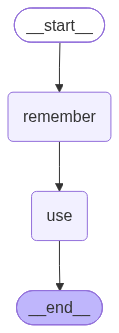

In [20]:
graph = StateGraph(State)
graph.add_node('remember', remember_preference)
graph.add_node('use', use_preference)
graph.add_edge(START, "remember")
graph.add_edge("remember", "use")
graph.add_edge("use", END)

app = graph.compile(store=store)
app

In [21]:
config1 = {"configurable": {"thread_id": "session1", "store": store}}
result1 = app.invoke({"user_id": "alice", "message": "hi"}, config=config1)
result1["message"]

"using preference: Item(namespace=['users', 'alice', 'preferences'], key='tone', value={'preferred_tone': 'friendly', 'auto_approve': True}, created_at='2026-08-20T15:51:02.196591+00:00', updated_at='2026-08-20T15:51:02.196592+00:00')"

In [23]:
config2 = {'configurable': {'thread_id': "session2", "store": store}}
result2 = app.invoke({"user_id": "alice", "message": "hi again"}, config = config2)
result2

{'user_id': 'alice',
 'message': "using preference: Item(namespace=['users', 'alice', 'preferences'], key='tone', value={'preferred_tone': 'friendly', 'auto_approve': True}, created_at='2026-08-20T15:54:16.121066+00:00', updated_at='2026-08-20T15:54:16.121068+00:00')"}